In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Extra Analysis: Constructing a Case with Negative Discrimination

This notebook is separate from the workshop activity. Its purpose is to investigate, in a controlled way, how negative discrimination can emerge in Beta4-IRT when the **response matrix itself** is perturbed.


## Why a Separate Notebook?

In CLAIRE, Beta4-IRT is fitted on the agreement-based response matrix `pij`, not on the external labels `y`.
Therefore, changing the labels alone may affect ARI, but it does **not necessarily** affect the estimated discriminations.

To study negative discrimination directly, we need to perturb the **partitions** produced by the model pool.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from birt import Beta4

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, MeanShift, OPTICS
from sklearn.metrics import adjusted_rand_score

from utils.transform import TransformPairwise
from utils.handson import beta4_expected_response


## Step 1: Generate a noisy-moons dataset


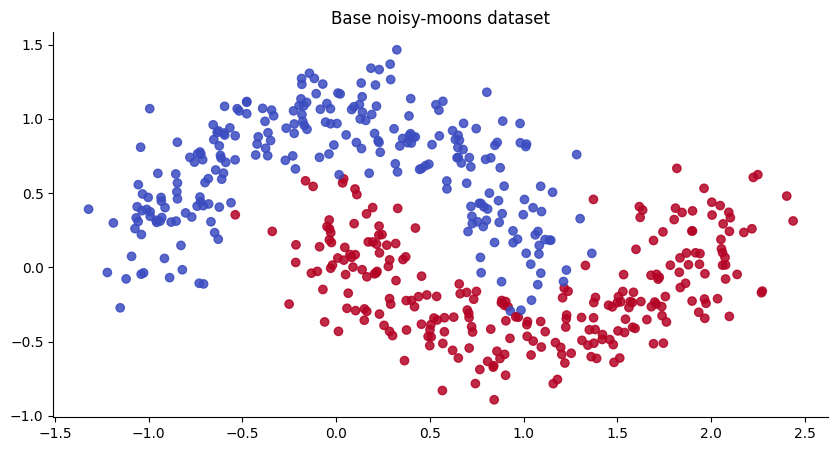

In [3]:
X, y = make_moons(n_samples=500, noise=0.18, random_state=11)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.85)
ax.set_title('Base noisy-moons dataset')
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Step 2: Fit a heterogeneous pool of clustering models


In [4]:
models = {
    **{f'KMeans_{i}': KMeans(n_clusters=i, random_state=1) for i in range(2, 6)},
    **{f'DBSCAN_{eps:.2f}': DBSCAN(eps=float(eps), min_samples=5) for eps in [0.15, 0.25, 0.35, 0.45, 0.55]},
    **{f'Spectral_{i}': SpectralClustering(n_clusters=i, random_state=1) for i in range(2, 6)},
    'MeanShift': MeanShift(),
    'OPTICS': OPTICS(min_samples=5),
}

partitions = pd.DataFrame(columns=models.keys())
results = []
for key, model in models.items():
    model.fit(X)
    partitions[key] = model.labels_
    results.append({'model': key, 'ari': adjusted_rand_score(y, model.labels_)})
results = pd.DataFrame(results).sort_values('ari', ascending=False)
results


,model,ari
13,MeanShift,0.403305
11,Spectral_4,0.344346
9,Spectral_2,0.290180
1,KMeans_3,0.285955
2,KMeans_4,0.278777
3,KMeans_5,0.257373
0,KMeans_2,0.248495
12,Spectral_5,0.202061
10,Spectral_3,0.189364
14,OPTICS,0.027934


## Step 3: Choose a subset of ambiguous instances

Here we pick instances close to the geometric center of the moons, where disagreement is more plausible.


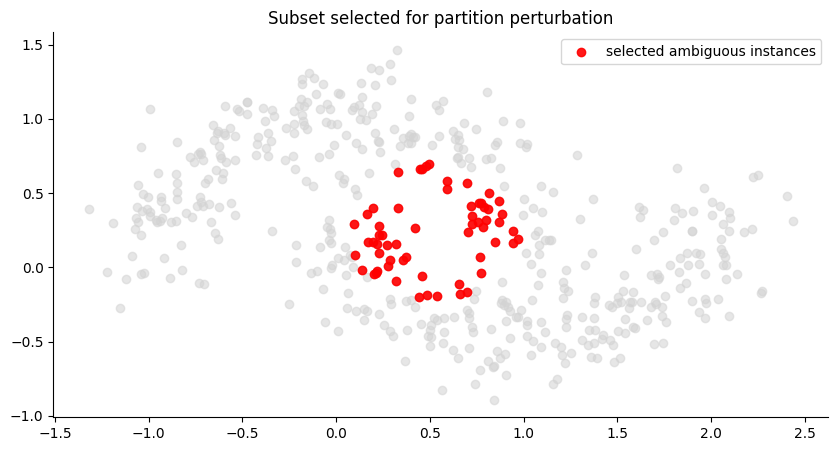

In [5]:
center = np.array([X[:, 0].mean(), X[:, 1].mean()])
distances = np.linalg.norm(X - center, axis=1)
ambiguous_idx = np.argsort(distances)[:60]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(X[:, 0], X[:, 1], c='lightgray', alpha=0.55)
ax.scatter(X[ambiguous_idx, 0], X[ambiguous_idx, 1], c='red', alpha=0.9, label='selected ambiguous instances')
ax.set_title('Subset selected for partition perturbation')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Step 4: Perturb the partitions directly

The idea is to change the responses of some strong models only on this subset, so that these instances become misleading from the perspective of agreement.


In [6]:
partitions_perturbed = partitions.copy()

strong_models = results.head(4)['model'].tolist()
weak_models = results.tail(4)['model'].tolist()

for model_name in strong_models:
    current = partitions_perturbed[model_name].to_numpy().copy()
    max_label = current.max() if current.max() >= 0 else 1
    current[ambiguous_idx] = (current[ambiguous_idx] + 1) % (max_label + 1 if max_label + 1 > 1 else 2)
    partitions_perturbed[model_name] = current

partitions_perturbed.head()


,KMeans_2,KMeans_3,KMeans_4,KMeans_5,DBSCAN_0.15,DBSCAN_0.25,DBSCAN_0.35,DBSCAN_0.45,DBSCAN_0.55,Spectral_2,Spectral_3,Spectral_4,Spectral_5,MeanShift,OPTICS
0,0,0,0,0,1,0,0,0,0,0,2,2,4,1,-1
1,0,0,0,0,0,0,0,0,0,0,2,2,4,1,-1
2,0,2,2,4,0,0,0,0,0,0,0,0,2,1,-1
3,0,0,2,4,0,0,0,0,0,0,2,0,1,1,7
4,1,1,1,1,0,0,0,0,0,1,0,1,3,0,24


## Step 5: Build `pij` and fit Beta4-IRT


In [7]:
tp = TransformPairwise(1)
pij = tp.generate_pij_matrix(partitions_perturbed)

birt = Beta4(
    learning_rate=1,
    epochs=10_000,
    n_respondents=pij.shape[1],
    n_items=pij.shape[0],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True,
)
birt.fit(pij.values)


  7%|▋         | 662/10000 [00:01<00:19, 474.39it/s]


Model converged at the 662th epoch


## Step 6: Inspect whether negative discrimination appears


In [8]:
discrimination_summary = pd.DataFrame(
    {
        'instance_id': np.arange(len(birt.discriminations)),
        'difficulty': birt.difficulties,
        'discrimination': birt.discriminations,
        'x1': X[:, 0],
        'x2': X[:, 1],
        'was_perturbed_region': np.isin(np.arange(len(X)), ambiguous_idx),
    }
).sort_values('discrimination')

discrimination_summary.head(20).round(4)


,instance_id,difficulty,discrimination,x1,x2,was_perturbed_region
194,194,0.4933,-0.5139,0.6965,0.5665,True
304,304,0.4973,-0.5015,0.0960,0.2941,True
331,331,0.4922,-0.4959,0.4456,0.6599,True
112,112,0.4922,-0.4959,0.4555,0.6654,True
269,269,0.4922,-0.4959,0.5912,0.5282,True
467,467,0.4922,-0.4959,0.4946,0.6948,True
168,168,0.4922,-0.4959,0.3274,0.6426,True
262,262,0.4922,-0.4959,0.5907,0.5814,True
6,6,0.4922,-0.4959,0.4773,0.6848,True
242,242,0.4924,-0.4398,0.1621,0.3602,True


In [9]:
print('Number of negative-discrimination instances:', int((birt.discriminations < 0).sum()))
print('Minimum estimated discrimination:', float(np.min(birt.discriminations)))


Number of negative-discrimination instances: 46
Minimum estimated discrimination: -0.5139457583427429


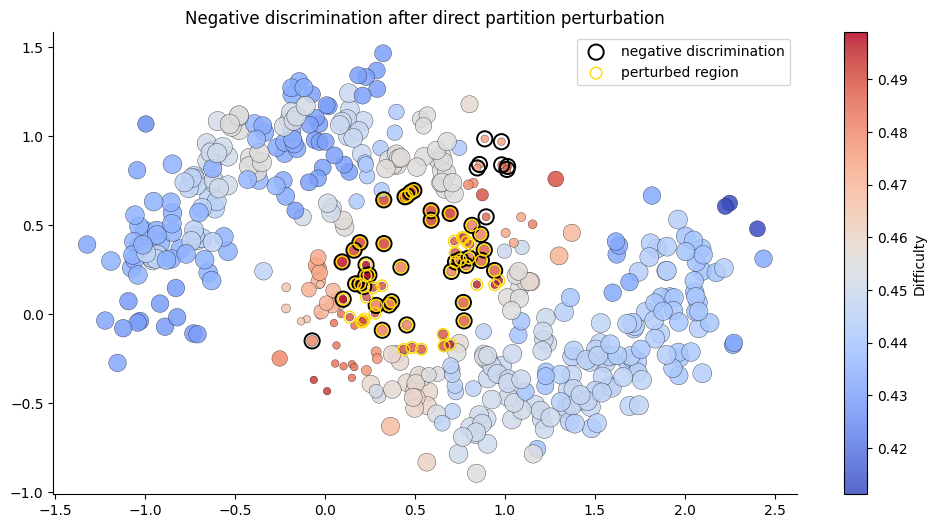

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sizes = np.clip(np.abs(birt.discriminations) * 200, 30, None)
sc = ax.scatter(X[:, 0], X[:, 1], c=birt.difficulties, cmap='coolwarm', s=sizes, alpha=0.85, edgecolor='k', linewidth=0.25)
neg_idx = np.where(birt.discriminations < 0)[0]
ax.scatter(X[neg_idx, 0], X[neg_idx, 1], facecolors='none', edgecolors='black', s=120, linewidth=1.4, label='negative discrimination')
ax.scatter(X[ambiguous_idx, 0], X[ambiguous_idx, 1], c='none', edgecolors='gold', s=70, linewidth=1.0, label='perturbed region')
fig.colorbar(sc, ax=ax, label='Difficulty')
ax.set_title('Negative discrimination after direct partition perturbation')
ax.legend(loc='best')
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Step 7: Inspect ICCs for the most negative and most positive items


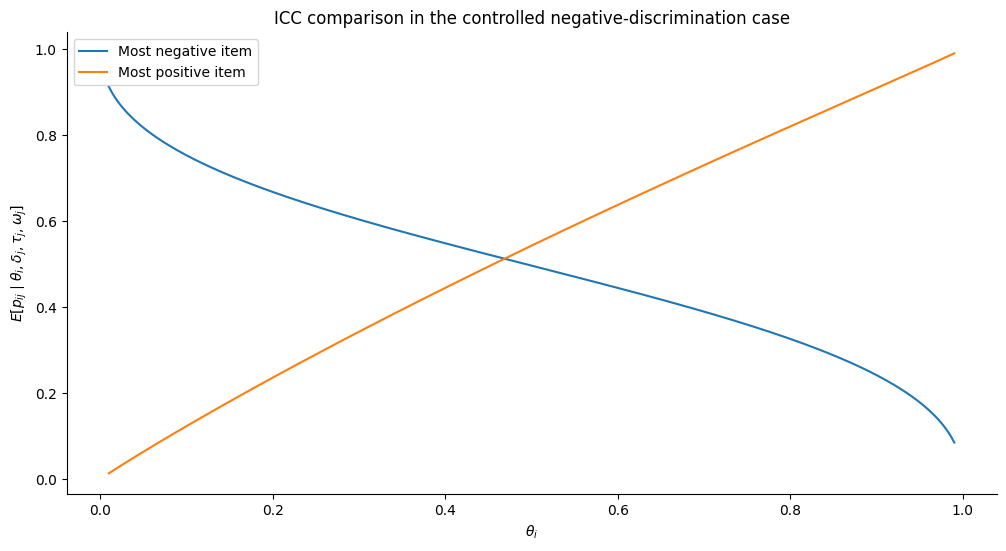

In [11]:
theta_grid = np.linspace(0.01, 0.99, 300)
most_negative_idx = int(np.argmin(birt.discriminations))
most_positive_idx = int(np.argmax(birt.discriminations))

neg_icc = beta4_expected_response(
    theta=theta_grid,
    difficulty=birt.difficulties[most_negative_idx],
    discrimination_sign=np.sign(birt.discriminations[most_negative_idx]),
    discrimination_magnitude=np.abs(birt.discriminations[most_negative_idx]),
)
pos_icc = beta4_expected_response(
    theta=theta_grid,
    difficulty=birt.difficulties[most_positive_idx],
    discrimination_sign=np.sign(birt.discriminations[most_positive_idx]),
    discrimination_magnitude=np.abs(birt.discriminations[most_positive_idx]),
)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(theta_grid, neg_icc, label='Most negative item')
ax.plot(theta_grid, pos_icc, label='Most positive item')
ax.set_title('ICC comparison in the controlled negative-discrimination case')
ax.set_xlabel(r'$\theta_i$')
ax.set_ylabel(r'$E[p_{ij} \mid \theta_i, \delta_j, \tau_j, \omega_j]$')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Closing Note

This notebook is not meant to be a standard workshop activity. It is a controlled analysis notebook whose only purpose is to help study how negative discrimination can emerge when the **agreement structure** is directly perturbed.
